# NLP - Elon Musk Tweets July, 2022 - June, 2023

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
import ollama
import os

from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

In [2]:
df = pd.read_csv('elon_musk_tweets.csv')

### Overview of data

In [3]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1544379368478212100,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240855,115,13503,True,2022-07-05 17:55:09+00:00,@BillyM2k I find the gold toe sock – inevitabl...,NaN,Twitter for iPhone,335,6542,False
1,1544377493263720450,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:47:42+00:00,"Sock Con, the conference for socks",NaN,Twitter for iPhone,1451,30753,False
2,1544377130590552064,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:46:15+00:00,Always something new for the magazine cover an...,NaN,Twitter for iPhone,1284,28610,False
3,1544375575724400645,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:40:05+00:00,@ExplainThisBob This guy gets it,NaN,Twitter for iPhone,131,3640,False
4,1544375148605853699,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:38:23+00:00,Sock tech is so advanced that you can get pret...,NaN,Twitter for iPhone,1191,23790,False


### Elon's tweeting Frequency

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_40604/2966624677.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  elon_musk_tweets['month'] = elon_musk_tweets['date'].dt.to_period('M').dt.to_timestamp()


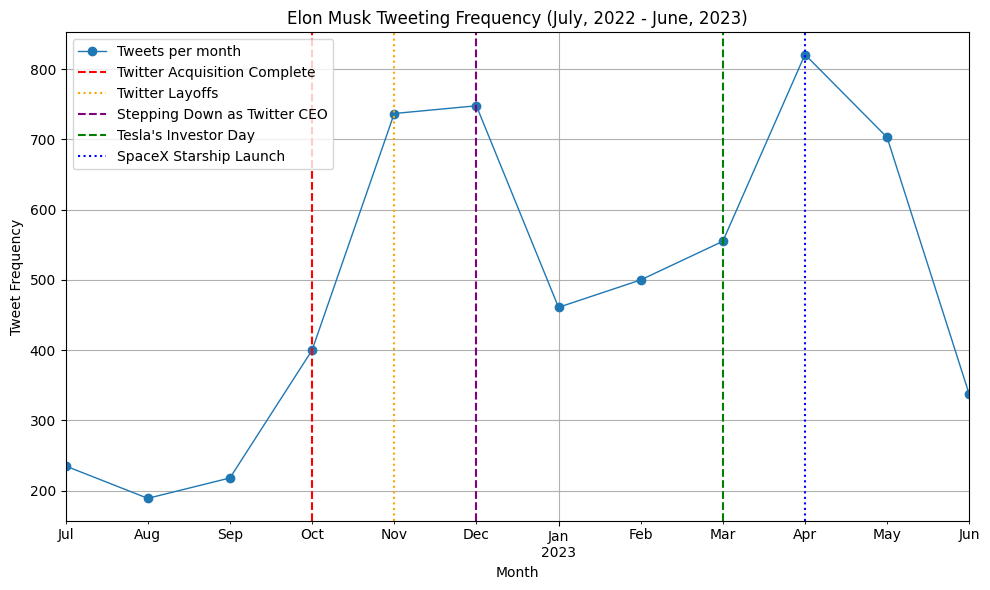

In [4]:
# Load your dataset (adjust the path as needed)
elon_musk_tweets = pd.read_csv('elon_musk_tweets.csv')

# Convert date column to datetime if not already done
elon_musk_tweets['date'] = pd.to_datetime(elon_musk_tweets['date'], errors='coerce')

# Extract the month for grouping
elon_musk_tweets['month'] = elon_musk_tweets['date'].dt.to_period('M').dt.to_timestamp()

# Plot tweeting frequency over time with additional events highlighted
fig, ax = plt.subplots(figsize=(10, 6))
elon_musk_tweets.groupby('month')['id'].count().plot(ax=ax, marker='o', lw=1, label='Tweets per month')

# Add styles to the plot
ax.set_xlabel('Month')
ax.set_ylabel('Tweet Frequency')
ax.set_title("Elon Musk Tweeting Frequency (July, 2022 - June, 2023)")

# Add vertical lines for important events in the given timeframe
ax.axvline('2022-10-27', color='red', linestyle='--', label='Twitter Acquisition Complete')
ax.axvline('2022-11-04', color='orange', linestyle=':', label='Twitter Layoffs')
ax.axvline('2022-12-20', color='purple', linestyle='--', label='Stepping Down as Twitter CEO')
ax.axvline('2023-03-01', color='green', linestyle='--', label="Tesla's Investor Day")
ax.axvline('2023-04-20', color='blue', linestyle=':', label='SpaceX Starship Launch')

# Final styling touches
ax.grid(True)
fig.tight_layout()
plt.legend()
plt.show()

## Pre-processing the text for NLP

In [5]:
def clean_text(text):
    # 1. Text Cleaning: Remove URLs, HTML tags, special characters, and numbers
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)    # Remove HTML tags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # Remove special characters and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespaces
    return text

def case_normalization(text):
    return text.lower()

def tokenization(text):
    return text.split()

stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stopwordlist]

lemmatizer = WordNetLemmatizer()

def lemmatize(tokens):
    # Perform lemmatization
    return [lemmatizer.lemmatize(token) for token in tokens]

In [6]:
elon_musk_tweets_cleaned = elon_musk_tweets
elon_musk_tweets_cleaned['text'] = elon_musk_tweets_cleaned['text'].apply(clean_text).apply(case_normalization).apply(tokenization).apply(remove_stopwords).apply(lemmatize)
print(elon_musk_tweets_cleaned['text'])

0       [billymk, find, gold, toe, sock, inevitably, k...
1                           [sock, con, conference, sock]
2       [always, something, new, magazine, cover, arti...
3                              [explainthisbob, guy, get]
4       [sock, tech, advanced, get, pretty, much, anyt...
                              ...                        
5899                            [jonerlichman, he, wrong]
5900           [alifarhat, guy, think, maybe, took, much]
5901                                      [sriramk, cool]
5902                     [cbdoge, time, complete, circle]
5903      [jason, late, stage, civilization, complacency]
Name: text, Length: 5904, dtype: object


## BoW

In [7]:
# Create a Bag of Words representation
def bag_of_words(tokens_list):
    # Flatten the list of tokenized documents (list of lists) into one list
    flat_tokens = [token for sublist in tokens_list for token in sublist]
    # Count the frequency of each word
    bow = Counter(flat_tokens)
    return bow

# Applying Bag of Words on the processed tokens
tokens = elon_musk_tweets_cleaned['text']
bow_result = bag_of_words(tokens)

# Displaying the Bag of Words result
print("Bag of Words Representation:")
for word, count in bow_result.most_common(10):  # Displaying top 10 words
    print(f"{word}: {count}")

Bag of Words Representation:
twitter: 448
amp: 333
billymk: 211
tesla: 207
wholemarsblog: 206
good: 195
true: 174
time: 165
people: 165
great: 158


"twitter" was most frequently used word on Elon's twitter in 2022-2023

## TF-IDF (Term Freuqncy-Invese Document Frequency)
Statistical measure used to evaluate how important a word is.
- Term Frequency (TF): This measures how frequently a term appears in a document.
- Inverse Document Frequency (IDF): This measures how important a term is. While computing TF, all terms are considered equally important. However, some terms like “is,” “of,” and “that” may appear frequently but have little importance. Thus, we need to weigh down the frequent terms while scaling up the rare ones by computing:

In [8]:
import pandas as pd
import math
from collections import Counter

# Assuming 'elon_musk_tweets_cleaned' is the DataFrame containing your cleaned and tokenized data

# Step 1: Group text data by month and combine tokens for each month
elon_musk_tweets_cleaned['month'] = elon_musk_tweets_cleaned['date'].dt.to_period('M').dt.to_timestamp()
grouped = elon_musk_tweets_cleaned.groupby('month')['text'].apply(lambda x: [token for sublist in x for token in sublist]).reset_index()

# Function to compute Term Frequency (TF)
def compute_tf(documents):
    tf_documents = []
    for document in documents:
        tf_doc = Counter(document)
        total_terms = len(document)
        for term in tf_doc:
            tf_doc[term] /= total_terms  # Normalize term frequency
        tf_documents.append(tf_doc)
    return tf_documents

# Function to compute Inverse Document Frequency (IDF)
def compute_idf(tf_documents):
    idf = {}
    total_documents = len(tf_documents)
    all_terms = set(term for tf_doc in tf_documents for term in tf_doc)
    for term in all_terms:
        containing_docs = sum(1 for tf_doc in tf_documents if term in tf_doc)
        idf[term] = math.log(total_documents / (1 + containing_docs))  # Apply IDF formula
    return idf

# Function to compute TF-IDF for each term in each document
def compute_tf_idf_manual(documents):
    tf_documents = compute_tf(documents)
    idf = compute_idf(tf_documents)
    tf_idf_documents = []
    for tf_doc in tf_documents:
        tf_idf_doc = {term: tf_value * idf[term] for term, tf_value in tf_doc.items()}
        tf_idf_documents.append(tf_idf_doc)
    return tf_idf_documents

# Apply TF-IDF computation to grouped data
grouped['tfidf'] = compute_tf_idf_manual(grouped['text'])

# Display the TF-IDF scores for each month
for idx, row in grouped.iterrows():
    print(f"Month: {row['month']}")
    print({k: v for k, v in sorted(row['tfidf'].items(), key=lambda item: item[1], reverse=True)[:10]})  # Top 10 words per month
    print()

Month: 2022-07-01 00:00:00
{'michaelsiconolf': 0.013054713801297304, 'kirstengrind': 0.009791035350972978, 'emilyglazer': 0.009791035350972978, 'sock': 0.006527356900648652, 'casparstanley': 0.005439464083873876, 'izanramos': 0.005439464083873876, 'nickcannon': 0.004351571267099102, 'ppathole': 0.0035998551961503073, 'pack': 0.003366835121116917, 'breitbartnews': 0.003263678450324326}

Month: 2022-08-01 00:00:00
{'culturaltutor': 0.0076772630758221785, 'mysa': 0.005670124902620427, 'happydad': 0.00425259367696532, 'wonderofscience': 0.00425259367696532, 'jonbbc': 0.00425259367696532, 'rationaletienne': 0.003290255603923791, 'arctechinc': 0.003290255603923791, 'sayssimonson': 0.0028350624513102133, 'cchomp': 0.0028350624513102133, 'softwareai': 0.0028350624513102133}

Month: 2022-09-01 00:00:00
{'ennnafnlaus': 0.010609102120429273, 'theliamnissan': 0.010609102120429273, 'treygahigh': 0.009430312995937131, 'rbreich': 0.008063527844049076, 'thejackbeyer': 0.0047151564979685655, 'bocachica

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_40604/1969402910.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  elon_musk_tweets_cleaned['month'] = elon_musk_tweets_cleaned['date'].dt.to_period('M').dt.to_timestamp()


## VADER Sentiment Analysis

In [9]:
!pip install vaderSentiment

### 1) Import and Set Up VADER

In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Define a function to perform sentiment analysis using VADER
def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    compound_score = sentiment['compound']  # We focus on the compound score for overall sentiment
    return compound_score

### 2) Test Sentiment Analysis Function

In [11]:
print(get_sentiment('I am very unhappy!'))
print(get_sentiment('I am happy!'))
print(get_sentiment('I am not happy!'))
print(get_sentiment('I am not not happy!'))

-0.5244
0.6114
-0.509
0.4158


### 3) Apply VADER Sentiment Analysis to Elon's Tweets

In [12]:
# Assuming elon_musk_tweets_cleaned is your DataFrame with cleaned data
# Applying sentiment analysis directly on the 'text' column (no preprocessing for negations)
elon_musk_tweets_cleaned['sentiment'] = elon_musk_tweets_cleaned['text'].apply(get_sentiment)

# Display the most negative and most positive messages
print("Most Negative Tweets:")
print(list(elon_musk_tweets_cleaned.sort_values(['sentiment'], ascending=True)['text'][:3]))

print("\nMost Positive Tweets:")
print(list(elon_musk_tweets_cleaned.sort_values(['sentiment'], ascending=False)['text'][:3]))

Most Negative Tweets:
[['terrible'], ['billymk', 'find', 'gold', 'toe', 'sock', 'inevitably', 'kilter', 'amp', 'washed', 'little', 'troubling', 'esthetically', 'amp', 'arguably', 'bit', 'corpo'], ['unusualwhales', 'phew', 'finally', 'sleep', 'night']]

Most Positive Tweets:
[['awesome'], ['true'], ['true']]


### 4) Analyze Sentiment Over Time (Monthly Analysis)

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_40604/1798786812.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  elon_musk_tweets_cleaned['month'] = elon_musk_tweets_cleaned['date'].dt.to_period('M').dt.to_timestamp()


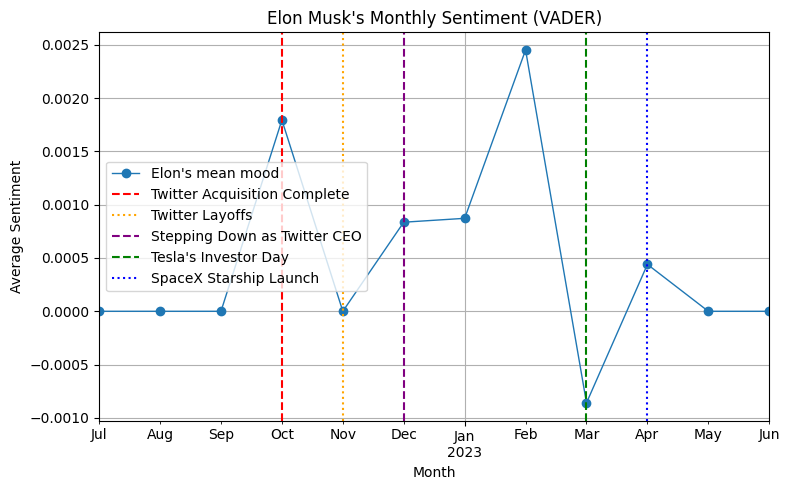

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by month to calculate the average sentiment per month
elon_musk_tweets_cleaned['month'] = elon_musk_tweets_cleaned['date'].dt.to_period('M').dt.to_timestamp()
monthly_sentiment = elon_musk_tweets_cleaned.groupby('month')['sentiment'].mean().reset_index()

# Plotting the sentiment trend over time
fig, ax = plt.subplots(figsize=(8, 5))
monthly_sentiment.plot(x='month', y='sentiment', ax=ax, marker='o', lw=1, label="Elon's mean mood")

# Adding labels and title
ax.set_xlabel('Month')
ax.set_ylabel('Average Sentiment')
ax.set_title("Elon Musk's Monthly Sentiment (VADER)")

# Add vertical lines for important events in the given timeframe
ax.axvline('2022-10-27', color='red', linestyle='--', label='Twitter Acquisition Complete')
ax.axvline('2022-11-04', color='orange', linestyle=':', label='Twitter Layoffs')
ax.axvline('2022-12-20', color='purple', linestyle='--', label='Stepping Down as Twitter CEO')
ax.axvline('2023-03-01', color='green', linestyle='--', label="Tesla's Investor Day")
ax.axvline('2023-04-20', color='blue', linestyle=':', label='SpaceX Starship Launch')

# Final styling touches
ax.grid(True)
fig.tight_layout()
plt.legend()
plt.show()

Elon has a very dry sentiment, as expected. 

# Topic Modelling

### 1) LDA

In [14]:
!pip install gensim

In [15]:
from gensim import corpora, models
import gensim

### Create Dictionary and Corpus

In [16]:
# Create a dictionary and corpus for LDA topic modeling
dictionary = corpora.Dictionary(elon_musk_tweets_cleaned['text'])
corpus = [dictionary.doc2bow(text) for text in elon_musk_tweets_cleaned['text']]

### Build LDA Model

In [17]:
# Build the LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=10,  # Adjust the number of topics as needed
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

### Print Topics 

In [18]:
# Print the topics discovered by the LDA model
topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.058*"think" + 0.043*"wholemarsblog" + 0.030*"people" + 0.030*"like" + 0.027*"many" + 0.018*"question" + 0.018*"even" + 0.017*"smokeawayyy" + 0.014*"lol" + 0.014*"teslaconomics"')
(1, '0.070*"civilization" + 0.030*"lot" + 0.023*"space" + 0.023*"billymk" + 0.017*"far" + 0.016*"zerohedge" + 0.013*"starlink" + 0.013*"peterdiamandis" + 0.013*"stclairashley" + 0.013*"thanks"')
(2, '0.072*"maybe" + 0.062*"late" + 0.059*"took" + 0.058*"good" + 0.056*"yeah" + 0.028*"titterdaily" + 0.020*"ai" + 0.018*"actually" + 0.016*"thebabylonbee" + 0.015*"point"')
(3, '0.085*"time" + 0.041*"platform" + 0.018*"one" + 0.017*"day" + 0.016*"post" + 0.016*"major" + 0.015*"way" + 0.014*"week" + 0.014*"farzyness" + 0.014*"stevenmarkryan"')
(4, '0.068*"jason" + 0.052*"complete" + 0.037*"interesting" + 0.025*"mattwalshblog" + 0.025*"davidsacks" + 0.022*"video" + 0.022*"stillgray" + 0.021*"coming" + 0.019*"year" + 0.019*"soon"')
(5, '0.055*"exactly" + 0.048*"wallstreetsilv" + 0.039*"teslaownerssv" + 0.031*"alx

### Simplified Topic Output

In [20]:
# Simplify LDA topics and store them in a list
simplified_topics = []
for topic_num, topic in topics:
    simplified_topic = " ".join([word.split("*")[1].replace('"', '').strip() for word in topic.split("+")])
    simplified_topics.append(simplified_topic)

# Display simplified topics
print("Simplified LDA Topics:")
for i, topic in enumerate(simplified_topics):
    print(f"Topic #{i + 1}: {topic}")

Simplified LDA Topics:
Topic #1: think wholemarsblog people like many question even smokeawayyy lol teslaconomics
Topic #2: civilization lot space billymk far zerohedge starlink peterdiamandis stclairashley thanks
Topic #3: maybe late took good yeah titterdaily ai actually thebabylonbee point
Topic #4: time platform one day post major way week farzyness stevenmarkryan
Topic #5: jason complete interesting mattwalshblog davidsacks video stillgray coming year soon
Topic #6: exactly wallstreetsilv teslaownerssv alx accurate know public want almost starship
Topic #7: cbdoge sriramk great dont therabbithole kanekoathegreat right communitynotes long endwokeness
Topic #8: much amp alifarhat stage twitter make spacex jordanbpeterson real really
Topic #9: also world better realdailywire love always high jonerlichman important idea
Topic #10: cool true guy tesla krassenstein would work get shellenberger team


To get a better feeling for the topics, let's find the top document for topic 4. These are the documents that best illustrates the topic.

In [21]:
# Analyze topic distribution for each document
doc_topics = [lda_model.get_document_topics(item) for item in corpus]

# Determine the top document for Topic 4 (zero-indexed, so Topic 4 is ID 3)
topic_id = 3
top_doc_for_topic_4, max_contribution = None, 0

for i, doc_distribution in enumerate(doc_topics):
    for topic_num, contrib in doc_distribution:
        if topic_num == topic_id and contrib > max_contribution:
            max_contribution = contrib
            top_doc_for_topic_4 = i

# Print results
if top_doc_for_topic_4 is not None:
    print(f"Top document for Topic 4 is Document #{top_doc_for_topic_4 + 1} with a contribution of {max_contribution:.4f}:")
    print(elon_musk_tweets_cleaned.iloc[top_doc_for_topic_4]['text'])
else:
    print("No document has Topic 4 as the predominant topic.")

Top document for Topic 4 is Document #84 with a contribution of 0.5104:
['arctechinc', 'go', 'internal', 'beta', 'tomorrow', 'external', 'next', 'week', 'handle', 'chuck', 'complex', 'left', 'turn', 'bet']


## Complementing LDA with Ollama

### 1) Define the Prompt

In [22]:
PROMPT = """I performed topic modeling on Elon Musk's tweets using LDA. The following is one of the simplified topics. 
Please provide a clear, concise label for the topic, along with a brief analysis of the key themes or insights based on the keywords.
Use bullet points for the analysis, and conclude with a single descriptive label."""

### 2) Simplify LDA Topics

In [23]:
# Simplify LDA topics and store them in a list
simplified_topics = []
for topic_num, topic in topics:  # Assuming 'topics' is the output of lda_model.print_topics()
    simplified_topic = " ".join([word.split("*")[1].replace('"', '').strip() for word in topic.split("+")])
    simplified_topics.append(simplified_topic)

# Display simplified topics
print("Simplified LDA Topics:")
for i, topic in enumerate(simplified_topics):
    print(f"Topic #{i + 1}: {topic}")

Simplified LDA Topics:
Topic #1: think wholemarsblog people like many question even smokeawayyy lol teslaconomics
Topic #2: civilization lot space billymk far zerohedge starlink peterdiamandis stclairashley thanks
Topic #3: maybe late took good yeah titterdaily ai actually thebabylonbee point
Topic #4: time platform one day post major way week farzyness stevenmarkryan
Topic #5: jason complete interesting mattwalshblog davidsacks video stillgray coming year soon
Topic #6: exactly wallstreetsilv teslaownerssv alx accurate know public want almost starship
Topic #7: cbdoge sriramk great dont therabbithole kanekoathegreat right communitynotes long endwokeness
Topic #8: much amp alifarhat stage twitter make spacex jordanbpeterson real really
Topic #9: also world better realdailywire love always high jonerlichman important idea
Topic #10: cool true guy tesla krassenstein would work get shellenberger team


### 3) Interpret Simplified Topics Using Ollama

In [24]:
# Function to interpret topics using Ollama
def interpret_topic_with_ollama(topic):
    response = ollama.chat(model='llama3', messages=[
        {
            'role': 'user',
            'content': f"{PROMPT}\n\n{topic}",
        }
    ])
    # Extract the message content directly
    return response['message']['content']

# Interpret simplified topics
interpreted_topics = []
for i, topic in enumerate(simplified_topics, start=1):
    try:
        print(f"Processing Topic #{i}...")
        interpreted_topic = interpret_topic_with_ollama(topic)
        interpreted_topics.append(interpreted_topic)
    except Exception as e:
        print(f"Error processing Topic #{i}: {e}")
        interpreted_topics.append("Error processing topic")

# Display interpreted topics
print("\nRaw Interpreted Topics:")
for i, topic in enumerate(interpreted_topics):
    print(f"Topic #{i + 1}: {topic}")

Processing Topic #1...
Processing Topic #2...
Processing Topic #3...
Processing Topic #4...
Processing Topic #5...
Processing Topic #6...
Processing Topic #7...
Processing Topic #8...
Processing Topic #9...
Processing Topic #10...

Raw Interpreted Topics:
Topic #1: Based on the keywords in this topic, I would suggest the following clear and concise label:

**"Tesla Fans and Critics"**

Analysis:

• The topic appears to be focused on Elon Musk's tweets about Tesla, with mentions of "wholemarsblog" (likely a reference to Whole Mars Catalog, a blog about space and technology) and "teslaconomics" (a play on the phrase "economics" that incorporates Tesla).
• The presence of "people like many question even" suggests that this topic may be discussing public perception or criticism of Elon Musk's views or actions related to Tesla.
• The inclusion of the phrase "smokeawayyy lol" implies a lighthearted or humorous tone, possibly indicating that the topic is not solely focused on negative critici

### 4) Clean the Interpreted Topics

In [25]:
# Clean interpreted topics to extract useful content
cleaned_interpreted_topics = []
for topic in interpreted_topics:
    try:
        if isinstance(topic, str):  # Ensure the response is a string
            cleaned_interpreted_topics.append(topic.strip())  # Strip unnecessary whitespace
        else:
            cleaned_interpreted_topics.append("Error processing topic: Unexpected structure")
    except Exception as e:
        print(f"Error cleaning topic: {e}")
        cleaned_interpreted_topics.append("Error processing topic")

# Display cleaned interpreted topics
print("\nCleaned Interpreted Topics:")
for i, topic in enumerate(cleaned_interpreted_topics):
    print(f"Topic #{i + 1}: {topic}")


Cleaned Interpreted Topics:
Topic #1: Based on the keywords in this topic, I would suggest the following clear and concise label:

**"Tesla Fans and Critics"**

Analysis:

• The topic appears to be focused on Elon Musk's tweets about Tesla, with mentions of "wholemarsblog" (likely a reference to Whole Mars Catalog, a blog about space and technology) and "teslaconomics" (a play on the phrase "economics" that incorporates Tesla).
• The presence of "people like many question even" suggests that this topic may be discussing public perception or criticism of Elon Musk's views or actions related to Tesla.
• The inclusion of the phrase "smokeawayyy lol" implies a lighthearted or humorous tone, possibly indicating that the topic is not solely focused on negative criticism.

Conclusive label: **Tesla Fans and Critics**
Topic #2: **Topic Label:** "Space Exploration and Futurism"

**Analysis:**

* The topic is heavily focused on themes related to space exploration, civilization, and the future.


### 5) Save to CSV

In [26]:
# Create a DataFrame for simplified and interpreted topics
topics_df = pd.DataFrame({
    'Simplified_Topic': simplified_topics,
    'Cleaned_Interpreted_Topic': cleaned_interpreted_topics
})

# Save the DataFrame to a CSV file
csv_path = 'interpreted_topics.csv'
try:
    topics_df.to_csv(csv_path, index=False)
    print(f"Topics saved to {csv_path}")
except Exception as e:
    print(f"Error saving to CSV: {e}")

Topics saved to interpreted_topics.csv
